# Proyecto final: análisis de Pokémon TCG

## Objetivo
Analizar la presencia de cartas y arquetipos de mazos en los torneos registrados entre 2011 y 2023, incorporando información del catálogo de cartas de Pokémon TCG.

## Herramientas
Python, Pandas, NumPy, Matplotlib y Power BI.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga de los datos

Cargamos los datos originales de torneos y del catálogo de cartas.
Después revisamos el número de filas y columnas de cada conjunto.

In [49]:
ruta_torneos = "../datos/brutos/tournaments.csv"
ruta_cartas = "../datos/brutos/pokemon-tcg-data-master 1999-2023.csv"

df_torneos = pd.read_csv(ruta_torneos)
df_cartas = pd.read_csv(ruta_cartas)

print("Dimensiones de torneos:", df_torneos.shape)
print("Dimensiones del catálogo:", df_cartas.shape)

Dimensiones de torneos: (114291, 26)
Dimensiones del catálogo: (17172, 29)


## 2. Exploración inicial

Revisamos ejemplos de los registros, los tipos de datos, los valores ausentes y las filas duplicadas antes de decidir cómo limpiarlos.

In [50]:
df_torneos.head()

,id_card,name_card,amount_card,price_card,energy_type_card,type_card,combo_type_id,combo_type_name,id_player,name_player,...,region_tournament,country_tournament,year_tournament,month_tournament,day_tournament,valid_rotation_at_tournament,rotation_name,year_begin,month_begin,day_begin
0,SSP272,Archeops,4,0.70,Colorless,Pokémon,247.0,Lugia Archeops,5101,Alexander Flatos,...,NaN,United States,2023,10,14,BST-OBF,standard_2023,2023,4,14
1,SIT138,Lugia V,3,6.20,Colorless,Pokémon,247.0,Lugia Archeops,5101,Alexander Flatos,...,NaN,United States,2023,10,14,BST-OBF,standard_2023,2023,4,14
2,SIT139,Lugia VSTAR,3,8.71,Colorless,Pokémon,247.0,Lugia Archeops,5101,Alexander Flatos,...,NaN,United States,2023,10,14,BST-OBF,standard_2023,2023,4,14
3,LOR143,Snorlax,3,0.93,Colorless,Pokémon,247.0,Lugia Archeops,5101,Alexander Flatos,...,NaN,United States,2023,10,14,BST-OBF,standard_2023,2023,4,14
4,SSP250,Lumineon V,2,1.90,Water,Pokémon,247.0,Lugia Archeops,5101,Alexander Flatos,...,NaN,United States,2023,10,14,BST-OBF,standard_2023,2023,4,14


In [51]:
df_cartas.head()

,id,set,series,publisher,generation,release_date,artist,name,set_num,types,...,retreatCost,convertedRetreatCost,rarity,flavorText,nationalPokedexNumbers,legalities,resistances,rules,regulationMark,ancientTrait
0,base1-1,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Alakazam,1,['Psychic'],...,"['Colorless', 'Colorless', 'Colorless']",3.0,Rare Holo,Its brain can outperform a supercomputer. Its ...,[65],{'unlimited': 'Legal'},NaN,NaN,NaN,NaN
1,base1-2,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Blastoise,2,['Water'],...,"['Colorless', 'Colorless', 'Colorless']",3.0,Rare Holo,A brutal Pokémon with pressurized water jets o...,[9],{'unlimited': 'Legal'},NaN,NaN,NaN,NaN
2,base1-3,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Chansey,3,['Colorless'],...,['Colorless'],1.0,Rare Holo,A rare and elusive Pokémon that is said to bri...,[113],{'unlimited': 'Legal'},"[{'type': 'Psychic', 'value': '-30'}]",NaN,NaN,NaN
3,base1-4,Base,Base,WOTC,First,1/9/1999,Mitsuhiro Arita,Charizard,4,['Fire'],...,"['Colorless', 'Colorless', 'Colorless']",3.0,Rare Holo,Spits fire that is hot enough to melt boulders...,[6],{'unlimited': 'Legal'},"[{'type': 'Fighting', 'value': '-30'}]",NaN,NaN,NaN
4,base1-5,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Clefairy,5,['Colorless'],...,['Colorless'],1.0,Rare Holo,Its magical and cute appeal has many admirers....,[35],{'unlimited': 'Legal'},"[{'type': 'Psychic', 'value': '-30'}]",NaN,NaN,NaN


In [52]:
print("INFORMACIÓN DE TORNEOS")
df_torneos.info()

print("\nINFORMACIÓN DEL CATÁLOGO")
df_cartas.info()

INFORMACIÓN DE TORNEOS
<class 'pandas.DataFrame'>
RangeIndex: 114291 entries, 0 to 114290
Data columns (total 26 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id_card                       114291 non-null  str    
 1   name_card                     114291 non-null  str    
 2   amount_card                   114291 non-null  int64  
 3   price_card                    110601 non-null  float64
 4   energy_type_card              42447 non-null   str    
 5   type_card                     114291 non-null  str    
 6   combo_type_id                 114244 non-null  float64
 7   combo_type_name               114244 non-null  str    
 8   id_player                     114291 non-null  int64  
 9   name_player                   114291 non-null  str    
 10  country_player                114291 non-null  str    
 11  all_time_score                114291 non-null  int64  
 12  ranking_player_tournament     11

In [53]:
print("NULOS EN TORNEOS")
print(df_torneos.isna().sum())

print("\nNULOS EN EL CATÁLOGO")
print(df_cartas.isna().sum())

print("\nFILAS DUPLICADAS EN TORNEOS:", df_torneos.duplicated().sum())
print("FILAS DUPLICADAS EN EL CATÁLOGO:", df_cartas.duplicated().sum())

NULOS EN TORNEOS
id_card                             0
name_card                           0
amount_card                         0
price_card                       3690
energy_type_card                71844
type_card                           0
combo_type_id                      47
combo_type_name                    47
id_player                           0
name_player                         0
country_player                      0
all_time_score                      0
ranking_player_tournament           0
id_tournament                       0
category_tournament                 0
name_tournament                     0
region_tournament               55879
country_tournament                  0
year_tournament                     0
month_tournament                    0
day_tournament                      0
valid_rotation_at_tournament    15605
rotation_name                       0
year_begin                          0
month_begin                         0
day_begin                        

## 3. Limpieza de los datos

Creamos copias de los datos para conservar los DataFrames originales.

En torneos se han detectado 84 filas identicas en todas sus columnas.
Conservamos una aparición de cada registro para evitar contar dos veces la misma información. El catálogo no contiene filas duplicadas exactas.

Los valores ausentes se revisarán según el significado de cada columna.

In [54]:
df_torneos_limpio = df_torneos.copy()
df_cartas_limpio = df_cartas.copy()

df_torneos_limpio = df_torneos_limpio.drop_duplicates()

print("Torneos antes:", df_torneos.shape)
print("Torneos después:", df_torneos_limpio.shape)
print("Catálogo:", df_cartas_limpio.shape)

print(
    "Duplicados restantes en torneos:",
    df_torneos_limpio.duplicated().sum()
)

Torneos antes: (114291, 26)
Torneos después: (114207, 26)
Catálogo: (17172, 29)
Duplicados restantes en torneos: 0


In [55]:
print("Registros por tipo de carta:")
print(df_torneos_limpio["type_card"].value_counts(dropna=False))

print("\nRegistros sin tipo de energía, agrupados por tipo de carta:")
print(
    df_torneos_limpio.loc[
        df_torneos_limpio["energy_type_card"].isna(),
        "type_card"
    ].value_counts(dropna=False)
)

Registros por tipo de carta:
type_card
Trainer    71790
Pokémon    42417
Name: count, dtype: int64

Registros sin tipo de energía, agrupados por tipo de carta:
type_card
Trainer    71790
Name: count, dtype: int64


### Tratamiento de valores ausentes en torneos

Los 71.790 valores ausentes de energy_type_card corresponden a cartas de Entrenador. Se sustituyen por "No aplica".

Los nombres de arquetipo, regiones y rotaciones ausentes se etiquetan como "Desconocido" para conservar los registros sin inventar información.

Los precios ausentes se mantienen como nulos, un precio desconocido no equivale a cero. Los identificadores de arquetipo ausentes también se conservan como nulos.

In [56]:
sin_tipo_entrenador = (
    df_torneos_limpio["type_card"].eq("Trainer")
    & df_torneos_limpio["energy_type_card"].isna()
)

df_torneos_limpio.loc[
    sin_tipo_entrenador, "energy_type_card"
] = "No aplica"

columnas_desconocidas = [
    "combo_type_name",
    "region_tournament",
    "valid_rotation_at_tournament"
]

for columna in columnas_desconocidas:
    df_torneos_limpio[columna] = (
        df_torneos_limpio[columna].fillna("Desconocido")
    )

print("Nulos restantes en torneos:")
print(df_torneos_limpio.isna().sum())

print("\nDimensiones:", df_torneos_limpio.shape)

Nulos restantes en torneos:
id_card                            0
name_card                          0
amount_card                        0
price_card                      3690
energy_type_card                   0
type_card                          0
combo_type_id                     47
combo_type_name                    0
id_player                          0
name_player                        0
country_player                     0
all_time_score                     0
ranking_player_tournament          0
id_tournament                      0
category_tournament                0
name_tournament                    0
region_tournament                  0
country_tournament                 0
year_tournament                    0
month_tournament                   0
day_tournament                     0
valid_rotation_at_tournament       0
rotation_name                      0
year_begin                         0
month_begin                        0
day_begin                          0
dtype: int

### Conversión de la fecha del torneo

Combinamos el año, mes y día del torneo en una columna de tipo fecha.
Esto facilitará ordenar los torneos y analizar su evolución temporal.

Comprobamos si hay fechas inválidas antes de continuar.

In [57]:
df_torneos_limpio["fecha_torneo"] = pd.to_datetime(
    {
        "year": df_torneos_limpio["year_tournament"],
        "month": df_torneos_limpio["month_tournament"],
        "day": df_torneos_limpio["day_tournament"]
    },
    errors="coerce"
)

print("Tipo de dato:", df_torneos_limpio["fecha_torneo"].dtype)

print(
    "Fechas inválidas:",
    df_torneos_limpio["fecha_torneo"].isna().sum()
)

print("Primera fecha:", df_torneos_limpio["fecha_torneo"].min())
print("Última fecha:", df_torneos_limpio["fecha_torneo"].max())

Tipo de dato: datetime64[us]
Fechas inválidas: 0
Primera fecha: 2011-08-13 00:00:00
Última fecha: 2023-10-14 00:00:00


In [58]:
df_torneos_limpio[
    [
        "year_tournament",
        "month_tournament",
        "day_tournament",
        "fecha_torneo"
    ]
].head()

,year_tournament,month_tournament,day_tournament,fecha_torneo
0,2023,10,14,2023-10-14
1,2023,10,14,2023-10-14
2,2023,10,14,2023-10-14
3,2023,10,14,2023-10-14
4,2023,10,14,2023-10-14


### Comprobación de cantidades, posiciones y registros

Revisamos las cantidades de cartas, las posiciones en los torneos y los precios para detectar valores que necesiten investigacion.

También comprobamos si una carta aparece en varias filas para el mismo jugador y torneo.

In [59]:
columnas_numericas = [
    "amount_card",
    "ranking_player_tournament",
    "price_card"
]

df_torneos_limpio[columnas_numericas].describe()

,amount_card,ranking_player_tournament,price_card
count,114207.000000,114207.000000,110517.000000
mean,2.150840,47.323229,1.995116
std,1.172452,42.013916,5.532745
min,1.000000,1.000000,0.020000
25%,1.000000,13.000000,0.170000
50%,2.000000,36.000000,0.640000
75%,3.000000,71.000000,2.160000
max,4.000000,193.000000,246.620000


In [60]:
print(
    "Cantidades cero o negativas:",
    (df_torneos_limpio["amount_card"] <= 0).sum()
)

print(
    "Posiciones cero o negativas:",
    (df_torneos_limpio["ranking_player_tournament"] <= 0).sum()
)

print(
    "Precios negativos:",
    (df_torneos_limpio["price_card"] < 0).sum()
)

clave_registro = ["id_tournament", "id_player", "id_card"]

print(
    "Repeticiones de carta para el mismo jugador y torneo:",
    df_torneos_limpio.duplicated(subset=clave_registro).sum()
)

Cantidades cero o negativas: 0
Posiciones cero o negativas: 0
Precios negativos: 0
Repeticiones de carta para el mismo jugador y torneo: 0


### Preparación de los nombres para la unión

Creamos una columna auxiliar en ambos conjuntos con los nombres en minúsculas y sin espacios al principio o al final.

Conservamos los nombres originales. No eliminamos símbolos ni sufijos, porque pueden distinguir cartas diferentes.

Antes de unir, revisamos cuántas entradas del catálogo comparten nombre.

In [61]:
df_torneos_limpio["nombre_union"] = (
    df_torneos_limpio["name_card"].str.strip().str.lower()
)

df_cartas_limpio["nombre_union"] = (
    df_cartas_limpio["name"].str.strip().str.lower()
)

print("Ejemplos de nombres en torneos:")
print(
    df_torneos_limpio[["name_card", "nombre_union"]].head()
)

print("\nEjemplos de nombres en el catálogo:")
print(
    df_cartas_limpio[["name", "nombre_union"]].head()
)

Ejemplos de nombres en torneos:
     name_card nombre_union
0     Archeops     archeops
1      Lugia V      lugia v
2  Lugia VSTAR  lugia vstar
3      Snorlax      snorlax
4   Lumineon V   lumineon v

Ejemplos de nombres en el catálogo:
        name nombre_union
0   Alakazam     alakazam
1  Blastoise    blastoise
2    Chansey      chansey
3  Charizard    charizard
4   Clefairy     clefairy


In [62]:
print("Filas del catálogo:", len(df_cartas_limpio))

print(
    "Identificadores únicos del catálogo:",
    df_cartas_limpio["id"].nunique()
)

print(
    "Nombres únicos del catálogo:",
    df_cartas_limpio["nombre_union"].nunique()
)

print("\nNombres con más entradas en el catálogo:")
print(df_cartas_limpio["nombre_union"].value_counts().head(10))

Filas del catálogo: 17172
Identificadores únicos del catálogo: 17172
Nombres únicos del catálogo: 3946

Nombres con más entradas en el catálogo:
nombre_union
pikachu       98
eevee         58
raichu        41
magnemite     41
charmander    38
magneton      36
unown         36
snorlax       35
magikarp      34
voltorb       32
Name: count, dtype: int64


### Resumen del catalogo por nombre

Agrupamos el catálogo por nombre normalizado y calculamos:

- Número de identificadores de carta distintos.
- Número de expansiones distintas.
- Número de artistas distintos conocidos.

Este resumen permite incorporar información del catálogo sin multiplicar las filas de torneos. Describe el catálogo completo descargado, no las ediciones disponibles en la fecha de cada torneo ni la edición utilizada

In [63]:
resumen_catalogo = (
    df_cartas_limpio.groupby("nombre_union")
    .agg(
        entradas_catalogo=("id", "nunique"),
        expansiones_catalogo=("set", "nunique"),
        artistas_catalogo=("artist", "nunique")
    )
    .reset_index()
)

print("Dimensiones del resumen:", resumen_catalogo.shape)

print(
    "Nombres duplicados en el resumen:",
    resumen_catalogo["nombre_union"].duplicated().sum()
)

resumen_catalogo.head()

Dimensiones del resumen: (3946, 4)
Nombres duplicados en el resumen: 0


,nombre_union,entradas_catalogo,expansiones_catalogo,artistas_catalogo
0,_____'s pikachu,2,2,1
1,aaron's collection,1,1,1
2,abomasnow,12,12,10
3,abra,8,8,5
4,absol,18,18,18


In [64]:
resumen_catalogo.loc[
    resumen_catalogo["nombre_union"] == "pikachu"
]

,nombre_union,entradas_catalogo,expansiones_catalogo,artistas_catalogo
2578,pikachu,98,73,48


## 4. Unión de los conjuntos de datos

Unimos los registros de torneos con el resumen del catálogo mediante el nombre normalizado.

Utilizamos una unión por la izquierda para conservar todos los registros de torneos, incluso si no encontramos su nombre en el catálogo

Comprobamos que cada nombre tenga una única fila en el resumen y registramos qué filas encuentran correspondencia.

In [65]:
df_completo = pd.merge(
    df_torneos_limpio,
    resumen_catalogo,
    on="nombre_union",
    how="left",
    validate="many_to_one",
    indicator="resultado_union"
)

print("Filas antes de unir:", len(df_torneos_limpio))
print("Dimensiones después de unir:", df_completo.shape)

print(
    "\n¿Se conserva el número de filas?",
    len(df_completo) == len(df_torneos_limpio)
)

print("\nResultado de la unión:")
print(df_completo["resultado_union"].value_counts())

Filas antes de unir: 114207
Dimensiones después de unir: (114207, 32)

¿Se conserva el número de filas? True

Resultado de la unión:
resultado_union
both          113247
left_only        960
right_only         0
Name: count, dtype: int64


In [66]:
porcentaje_coincidencia = (
    df_completo["resultado_union"].eq("both").mean() * 100
)

print(f"Registros con correspondencia: {porcentaje_coincidencia:.4f}%")

print("\nNombres sin correspondencia más frecuentes:")
print(
    df_completo.loc[
        df_completo["resultado_union"] == "left_only",
        "name_card"
    ].value_counts().head(20)
)

Registros con correspondencia: 99.1594%

Nombres sin correspondencia más frecuentes:
name_card
Tapu Koko ♢             192
Ditto ♢                 187
Thunder Mountain ♢      174
Heat Factory ♢           87
Battle Compressor        71
Diancie ♢                55
Wondrous Labyrinth ♢     34
Target Whistle           28
Victini ♢                28
Head Ringer              18
Jirachi ♢                10
Lusamine ♢               10
Life Forest ♢             9
Volcanion ♢               7
Shaymin ♢                 7
Lunala ♢                  6
Xerneas ♢                 6
Black Market ♢            6
Latias ♢                  5
Robo Substitute           4
Name: count, dtype: int64


### Revisión de nombres sin correspondencia

La unión mantiene 114.207 filas y obtiene correspondencia para 113.247 registros (99,16%). Los 960 restantes se conservan.

Revisamos posibles diferencias de escritura entre las fuentes antes de aplicar correcciones. Los datos del catálogo que no se han podido incorporar permanecen como nulos, no como ceros.

In [67]:
nombres_a_revisar = [
    "tapu koko",
    "ditto",
    "thunder mountain",
    "battle compressor",
    "target whistle",
    "head ringer"
]

for nombre in nombres_a_revisar:
    print(f"\nCoincidencias para: {nombre}")

    coincidencias = df_cartas_limpio.loc[
        df_cartas_limpio["nombre_union"].str.contains(
            nombre,
            regex=False,
            na=False
        ),
        ["name", "nombre_union"]
    ].drop_duplicates()

    print(coincidencias.to_string(index=False))


Coincidencias para: tapu koko
          name   nombre_union
     Tapu Koko      tapu koko
  Tapu Koko-GX   tapu koko-gx
   Tapu Koko ◇    tapu koko ◇
   Tapu Koko V    tapu koko v
Tapu Koko VMAX tapu koko vmax
  Tapu Koko ex   tapu koko ex

Coincidencias para: ditto
        name nombre_union
       Ditto        ditto
Koga's Ditto koga's ditto
     Ditto ◇      ditto ◇
     Ditto V      ditto v
  Ditto VMAX   ditto vmax

Coincidencias para: thunder mountain
              name       nombre_union
Thunder Mountain ◇ thunder mountain ◇

Coincidencias para: battle compressor
                             name                      nombre_union
Battle Compressor Team Flare Gear battle compressor team flare gear

Coincidencias para: target whistle
                          name                   nombre_union
Target Whistle Team Flare Gear target whistle team flare gear

Coincidencias para: head ringer
                             name                      nombre_union
Head Ringer Team Flare Hyp

### Normalización del símbolo de diamante

Se detectan dos caracteres distintos para el símbolo de diamante: ♢ en torneos y ◇ en el catálogo.

Unificamos ambos como ◇ en la columna auxiliar nombre_union.
Conservamos los nombres originales y el símbolo para no mezclar estas cartas con otras versiones sin diamante.

Después repetimos la unión y comprobamos su cobertura.

In [68]:
df_torneos_limpio["nombre_union"] = (
    df_torneos_limpio["nombre_union"]
    .str.replace("♢", "◇", regex=False)
)

df_cartas_limpio["nombre_union"] = (
    df_cartas_limpio["nombre_union"]
    .str.replace("♢", "◇", regex=False)
)

In [69]:
busquedas_pendientes = [
    "battle compressor",
    "target whistle",
    "head ringer",
    "robo substitute",
    "flab",
    "palace",
    "gym medal"
]

for texto in busquedas_pendientes:
    print(f"\nBúsqueda: {texto}")

    coincidencias = df_cartas_limpio.loc[
        df_cartas_limpio["nombre_union"].str.contains(
            texto,
            regex=False,
            na=False
        ),
        ["id", "name", "supertype", "rules"]
    ]

    print(coincidencias.to_string(index=False))


Búsqueda: battle compressor
    id                              name supertype                                                                                                                                                                       rules
xy4-92 Battle Compressor Team Flare Gear   Trainer ['Search your deck for up to 3 cards and discard them. Shuffle your deck afterward.', 'You may play as many Item cards as you like during your turn (before your attack).']

Búsqueda: target whistle
     id                           name supertype                                                                                                                                                                  rules
xy4-106 Target Whistle Team Flare Gear   Trainer ["Put a Basic Pokémon from your opponent's discard pile onto his or her Bench.", 'You may play as many Item cards as you like during your turn (before your attack).']

Búsqueda: head ringer
    id                              name sup

### Equivalencias de nombres entre las fuentes

Tras revisar los nombres y las características disponibles en el catálogo, aplicamos cinco equivalencias explícitas: cuatro nombres abreviados de cartas Team Flare y Flabebe a Flabébé.

Las equivalencias se aplican únicamente a nombre_union y permiten incorporar el resumen por nombre del catálogo, no identificar la edición concreta utilizada en un torneo.

Palace Book y Pokemon Card Gym Medal se mantienen sin correspondencia.
Sus datos del catálogo permanecen como nulos.

In [70]:
equivalencias_nombres = {
    "battle compressor": "battle compressor team flare gear",
    "target whistle": "target whistle team flare gear",
    "head ringer": "head ringer team flare hyper gear",
    "robo substitute": "robo substitute team flare gear",
    "flabebe": "flabébé"
}

df_torneos_limpio["nombre_union"] = (
    df_torneos_limpio["nombre_union"]
    .replace(equivalencias_nombres)
)

### Unión definitiva tras corregir los nombres

Reconstruimos el resumen del catálogo y repetimos la unión después de aplicar las correcciones. Así, el notebook obtiene el resultado final al ejecutar todas las celdas en orden.

In [71]:
resumen_catalogo = (
    df_cartas_limpio.groupby("nombre_union")
    .agg(
        entradas_catalogo=("id", "nunique"),
        expansiones_catalogo=("set", "nunique"),
        artistas_catalogo=("artist", "nunique")
    )
    .reset_index()
)

df_completo = pd.merge(
    df_torneos_limpio,
    resumen_catalogo,
    on="nombre_union",
    how="left",
    validate="many_to_one",
    indicator="resultado_union"
)

print("Dimensiones finales:", df_completo.shape)
print("\nResultado de la unión definitiva:")
print(df_completo["resultado_union"].value_counts())

Dimensiones finales: (114207, 32)

Resultado de la unión definitiva:
resultado_union
both          114202
left_only          5
right_only         0
Name: count, dtype: int64


### Resultado de la unión

La unión conserva las 114.207 filas de torneos y obtiene un conjunto de 32 columnas, superando los mínimos de tamaño del proyecto.

Se encuentra correspondencia para 114.202 registros (99,9956 %).
Quedan cinco registros sin correspondencia: tres de Palace Book y dos de Pokemon Card Gym Medal.

Estos registros se conservan y sus campos del catálogo permanecen como nulos. No se sustituyen por cero, porque no conocemos esos datos.

In [72]:
print("Dimensiones:", df_completo.shape)

print("\nResultado de la unión:")
print(df_completo["resultado_union"].value_counts())

print("\nNulos en las columnas incorporadas:")
print(
    df_completo[
        [
            "entradas_catalogo",
            "expansiones_catalogo",
            "artistas_catalogo"
        ]
    ].isna().sum()
)

Dimensiones: (114207, 32)

Resultado de la unión:
resultado_union
both          114202
left_only          5
right_only         0
Name: count, dtype: int64

Nulos en las columnas incorporadas:
entradas_catalogo       5
expansiones_catalogo    5
artistas_catalogo       5
dtype: int64


## 5. Análisis descriptivo

### Tamaño y cobertura de los datos

Cada fila representa una carta dentro del mazo de un jugador en un torneo. La columna amount_card indica cuántas copias lleva.

Identificamos cada mazo mediante la combinación de torneo y jugador.
Un jugador puede aparecer en varios torneos.

Los recuentos describen los registros disponibles en el conjunto, no necesariamente todos los participantes de cada torneo.

In [73]:
numero_mazos = (
    df_completo[["id_tournament", "id_player"]]
    .drop_duplicates()
    .shape[0]
)

print("Registros de cartas:", len(df_completo))
print("Mazos registrados:", numero_mazos)
print("Jugadores distintos:", df_completo["id_player"].nunique())
print("Torneos distintos:", df_completo["id_tournament"].nunique())
print("Identificadores de carta distintos:", df_completo["id_card"].nunique())
print("Nombres de carta distintos:", df_completo["nombre_union"].nunique())

Registros de cartas: 114207
Mazos registrados: 5003
Jugadores distintos: 2656
Torneos distintos: 133
Identificadores de carta distintos: 1707
Nombres de carta distintos: 1323


In [74]:
cobertura_anual = (
    df_completo[
        ["year_tournament", "id_tournament", "id_player"]
    ]
    .drop_duplicates()
    .groupby("year_tournament")
    .agg(
        torneos_registrados=("id_tournament", "nunique"),
        mazos_registrados=("id_player", "size"),
        jugadores_distintos=("id_player", "nunique")
    )
)

cobertura_anual

,torneos_registrados,mazos_registrados,jugadores_distintos
year_tournament,,,
2011,1,9,9
2012,1,6,6
2013,4,25,25
2014,5,45,44
2015,5,73,65
2016,7,90,85
2017,5,128,100
2018,9,293,239
2019,16,503,392


### Nombres de carta más presentes en los mazos

Calculamos en cuántos mazos registrados aparece cada nombre de carta y qué porcentaje representa sobre los 5.003 mazos disponibles

Cada nombre se cuenta una sola vez por combinación de jugador y torneo.
El análisis agrupa por nombre, no por edición ni por características idénticas de juego.

El ranking describe el conjunto completo y está condicionado por la mayor cobertura de los años recientes. No mide la tasa de victoria.

In [75]:
presencia_cartas = df_completo[
    ["id_tournament", "id_player", "nombre_union"]
].drop_duplicates()

ranking_cartas = (
    presencia_cartas.groupby("nombre_union")
    .size()
    .reset_index(name="mazos_con_carta")
)

ranking_cartas["porcentaje_mazos"] = (
    ranking_cartas["mazos_con_carta"] / numero_mazos * 100
)

ranking_cartas = ranking_cartas.sort_values(
    ["mazos_con_carta", "nombre_union"],
    ascending=[False, True]
)

ranking_cartas.head(15).round(2)

,nombre_union,mazos_con_carta,porcentaje_mazos
1213,ultra ball,3694,73.84
109,boss's orders,3411,68.18
342,escape rope,2422,48.41
803,nest ball,2032,40.62
66,battle vip pass,2007,40.12
903,professor's research,1963,39.24
176,choice belt,1926,38.50
714,manaphy,1795,35.88
911,quick ball,1770,35.38
652,lost vacuum,1659,33.16


### Visualización de los nombres de carta más presentes

Ultra Ball aparece en el 73,84 % de los mazos registrados, seguida de Boss’s Orders (68,18 %) y Escape Rope (48,41 %).

Estos porcentajes describen la presencia en los mazos disponibles, no la probabilidad de ganar. El resultado global está especialmente influido por 2023, que aporta 3.060 de los 5.003 mazos.

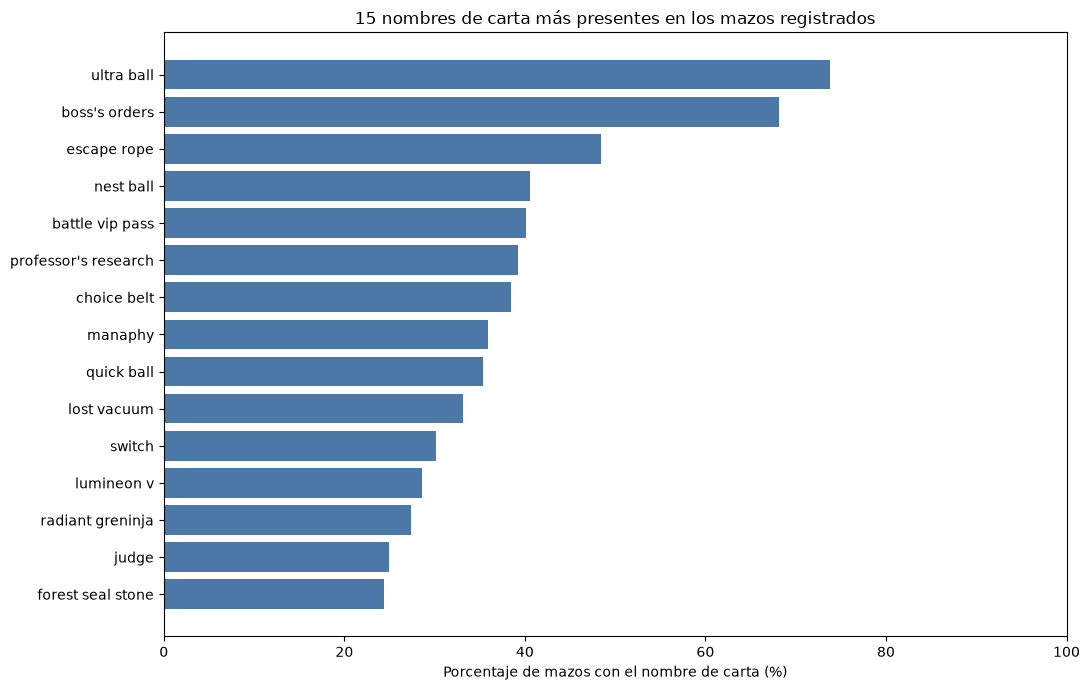

In [76]:
top_15_cartas = ranking_cartas.head(15).sort_values(
    "porcentaje_mazos",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_15_cartas["nombre_union"],
    top_15_cartas["porcentaje_mazos"],
    color="#4C78A8"
)

plt.title("15 nombres de carta más presentes en los mazos registrados")
plt.xlabel("Porcentaje de mazos con el nombre de carta (%)")
plt.ylabel("")
plt.xlim(0, 100)

plt.tight_layout()

plt.savefig(
    "../imagenes/01_presencia_cartas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Evolución anual de la presencia de cartas

Seleccionamos los cinco nombres más presentes en el conjunto completo y calculamos qué porcentaje de los mazos registrados en cada año contiene cada uno.

Esto permite comparar años con distinto número de mazos. Sin embargo, los años con pocos registros ofrecen resultados menos estables.
La selección de estos cinco nombres también está influida por la mayor cobertura de los años recientes.

In [77]:
top_5_nombres = ranking_cartas.head(5)["nombre_union"].tolist()

presencia_anual = df_completo[
    [
        "year_tournament",
        "id_tournament",
        "id_player",
        "nombre_union"
    ]
].drop_duplicates()

presencia_anual_top5 = presencia_anual.loc[
    presencia_anual["nombre_union"].isin(top_5_nombres)
]

conteo_anual = (
    presencia_anual_top5.groupby(
        ["year_tournament", "nombre_union"]
    )
    .size()
    .reset_index(name="mazos_con_carta")
)

evolucion_cartas = conteo_anual.merge(
    cobertura_anual[["mazos_registrados"]],
    left_on="year_tournament",
    right_index=True,
    how="left",
    validate="many_to_one"
)

evolucion_cartas["porcentaje_mazos"] = (
    evolucion_cartas["mazos_con_carta"]
    / evolucion_cartas["mazos_registrados"]
    * 100
)

evolucion_cartas.head(15).round(2)

,year_tournament,nombre_union,mazos_con_carta,mazos_registrados,porcentaje_mazos
0,2012,ultra ball,4,6,66.67
1,2013,escape rope,1,25,4.00
2,2013,ultra ball,25,25,100.00
3,2014,escape rope,13,45,28.89
4,2014,ultra ball,45,45,100.00
5,2015,escape rope,11,73,15.07
6,2015,ultra ball,70,73,95.89
7,2016,escape rope,29,90,32.22
8,2016,ultra ball,88,90,97.78
9,2017,escape rope,12,128,9.38


### Tabla anual de presencia

Reorganizamos los resultados para comparar los porcentajes por año.
Cuando una carta no aparece en los mazos registrados de un año, se muestra un 0%.

Los ceros significan que no se observa esa carta en los datos disponibles para ese año. Los resultados de 2011 y 2012 deben interpretarse con especial cautela porque solo contienen 9 y 6 mazos.

In [78]:
tabla_evolucion = evolucion_cartas.pivot_table(
    index="year_tournament",
    columns="nombre_union",
    values="porcentaje_mazos",
    fill_value=0
)

tabla_evolucion = tabla_evolucion.reindex(
    index=cobertura_anual.index,
    columns=top_5_nombres,
    fill_value=0
)

tabla_evolucion.round(2)

nombre_union,ultra ball,boss's orders,escape rope,nest ball,battle vip pass
year_tournament,,,,,
2011,0.00,0.00,0.00,0.00,0.00
2012,66.67,0.00,0.00,0.00,0.00
2013,100.00,0.00,4.00,0.00,0.00
2014,100.00,0.00,28.89,0.00,0.00
2015,95.89,0.00,15.07,0.00,0.00
2016,97.78,0.00,32.22,0.00,0.00
2017,99.22,0.00,9.38,4.69,0.00
2018,96.93,0.00,8.53,35.15,0.00
2019,53.68,0.00,22.66,52.49,0.00


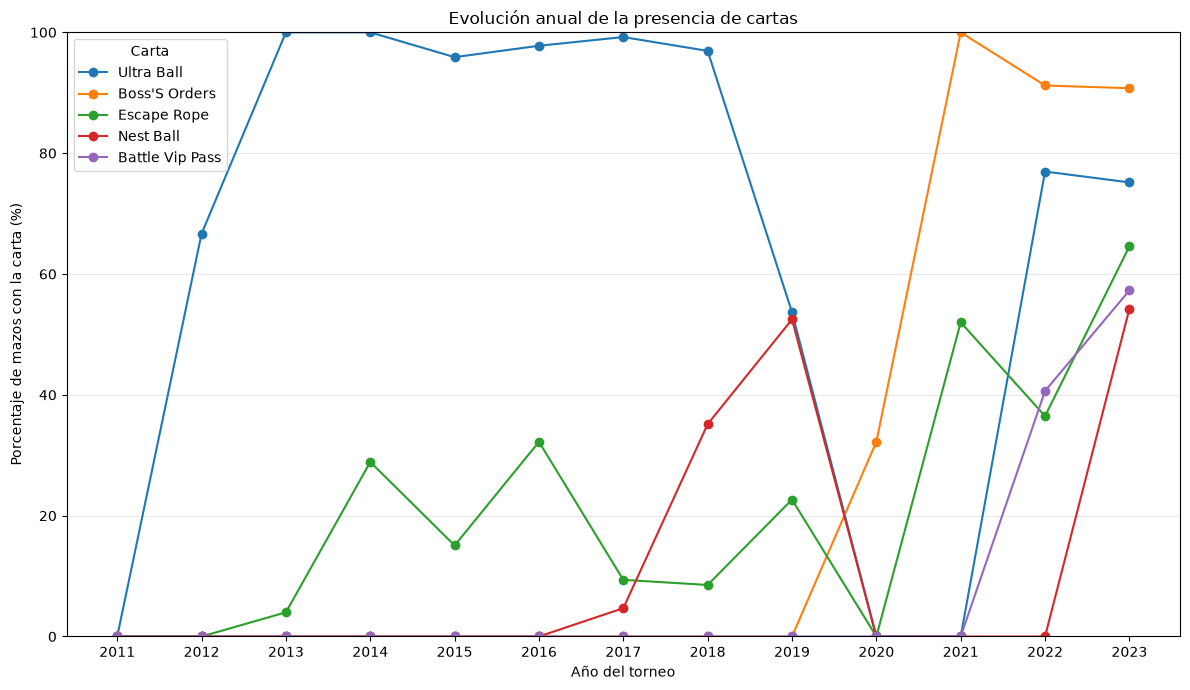

In [79]:
plt.figure(figsize=(12, 7))

for nombre in top_5_nombres:
    plt.plot(
        tabla_evolucion.index,
        tabla_evolucion[nombre],
        marker="o",
        label=nombre.title()
    )

plt.title("Evolución anual de la presencia de cartas")
plt.xlabel("Año del torneo")
plt.ylabel("Porcentaje de mazos con la carta (%)")
plt.xticks(tabla_evolucion.index)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Carta")

plt.tight_layout()

plt.savefig(
    "../imagenes/02_evolucion_anual_cartas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

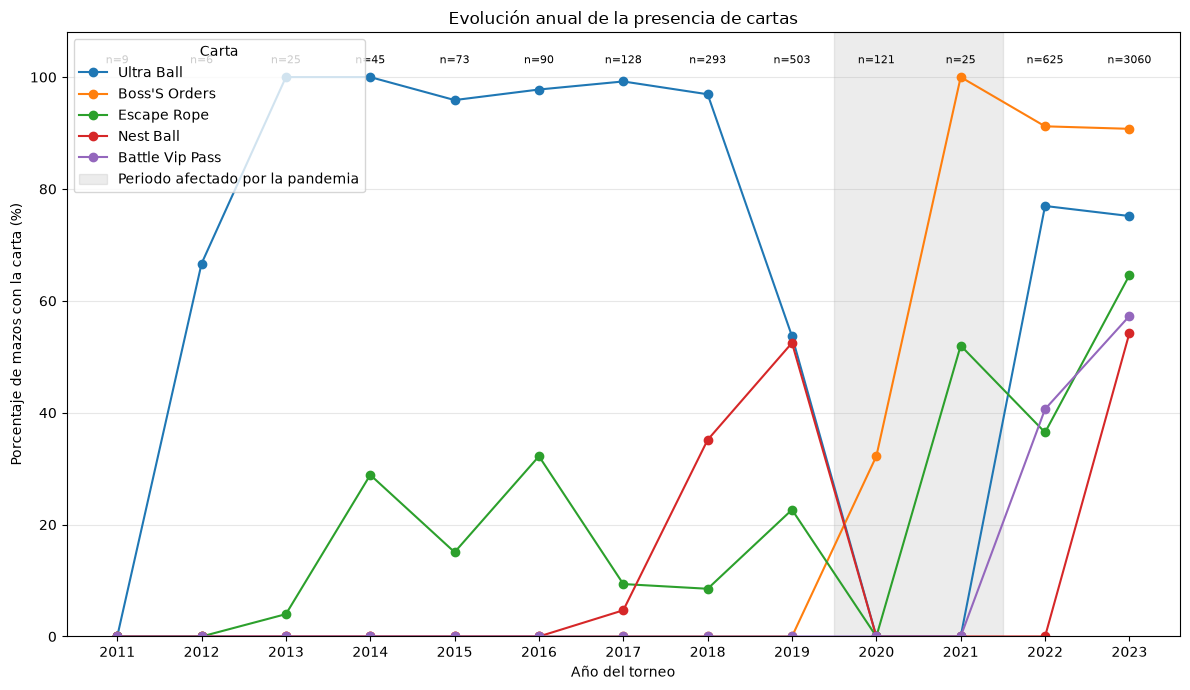

In [80]:
plt.figure(figsize=(12, 7))

for nombre in top_5_nombres:
    plt.plot(
        tabla_evolucion.index,
        tabla_evolucion[nombre],
        marker="o",
        label=nombre.title()
    )

plt.axvspan(
    2019.5,
    2021.5,
    color="gray",
    alpha=0.15,
    label="Periodo afectado por la pandemia"
)

for anio in cobertura_anual.index:
    numero = cobertura_anual.loc[anio, "mazos_registrados"]

    plt.text(
        anio,
        102,
        f"n={numero}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.title("Evolución anual de la presencia de cartas")
plt.xlabel("Año del torneo")
plt.ylabel("Porcentaje de mazos con la carta (%)")
plt.xticks(tabla_evolucion.index)
plt.ylim(0, 108)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Carta", loc="upper left")

plt.tight_layout()

plt.savefig(
    "../imagenes/02_evolucion_anual_cartas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La fuerte reducción de torneos y mazos registrados durante 2020 y 2021 coincide con la suspensión de gran parte de las competiciones presenciales de Play! Pokémon durante la pandemia. El conjunto contiene 121 mazos en 2020 y solo 25 en 2021, estos últimos procedentes de dos torneos asiáticos.

Por ello, porcentajes como el 100% de Boss's Orders en 2021 no deben generalizarse al conjunto de jugadores competitivos de ese año.

Los cambios también están afectados por la aparición y rotación de cartas en el formato competitivo. Una presencia del 0% puede indicar que la carta todavía no estaba disponible, no formaba parte del formato o no apareció en los pocos torneos registrados. Este gráfico describe la muestra disponible y no demuestra por sí solo cambios generales del metajuego.

### Preparación de una tabla de mazos

El conjunto completo contiene una fila por carta incluida en un mazo.
Para analizar arquetipos y posiciones necesitamos una tabla con una sola fila por combinación de torneo y jugador.

Antes de crearla, comprobamos que cada mazo tenga un único arquetipo y una única posición dentro del torneo.

In [81]:
comprobacion_mazos = (
    df_completo.groupby(["id_tournament", "id_player"])
    .agg(
        numero_arquetipos=("combo_type_name", "nunique"),
        numero_posiciones=("ranking_player_tournament", "nunique")
    )
)

print(
    "Mazos con más de un arquetipo:",
    (comprobacion_mazos["numero_arquetipos"] > 1).sum()
)

print(
    "Mazos con más de una posición:",
    (comprobacion_mazos["numero_posiciones"] > 1).sum()
)

Mazos con más de un arquetipo: 0
Mazos con más de una posición: 0


In [82]:
columnas_mazos = [
    "id_tournament",
    "id_player",
    "name_player",
    "country_player",
    "combo_type_name",
    "ranking_player_tournament",
    "all_time_score",
    "category_tournament",
    "name_tournament",
    "country_tournament",
    "region_tournament",
    "year_tournament",
    "fecha_torneo",
    "rotation_name"
]

df_mazos = (
    df_completo[columnas_mazos]
    .drop_duplicates(
        subset=["id_tournament", "id_player"]
    )
    .copy()
)

print("Dimensiones de la tabla de mazos:", df_mazos.shape)
print("Arquetipos distintos:", df_mazos["combo_type_name"].nunique())
print("Mazos con arquetipo desconocido:", (
    df_mazos["combo_type_name"] == "Desconocido"
).sum())

Dimensiones de la tabla de mazos: (5003, 14)
Arquetipos distintos: 377
Mazos con arquetipo desconocido: 2


In [83]:
ranking_arquetipos = (
    df_mazos.groupby("combo_type_name")
    .agg(
        mazos_registrados=("id_player", "size"),
        jugadores_distintos=("id_player", "nunique"),
        torneos_distintos=("id_tournament", "nunique")
    )
    .reset_index()
)

ranking_arquetipos["porcentaje_mazos"] = (
    ranking_arquetipos["mazos_registrados"]
    / len(df_mazos)
    * 100
)

ranking_arquetipos = ranking_arquetipos.sort_values(
    "mazos_registrados",
    ascending=False
)

ranking_arquetipos.head(15).round(2)

,combo_type_name,mazos_registrados,jugadores_distintos,torneos_distintos,porcentaje_mazos
190,Lugia Archeops,814,578,53,16.27
185,Lost Zone Box,437,307,51,8.73
214,Mew Genesect,306,238,47,6.12
132,Gardevoir,274,209,33,5.48
125,Fusion Mew,206,159,48,4.12
264,Regis,132,97,23,2.64
144,Goodra LZ Box,131,111,32,2.62
141,Giratina LZ Box,119,111,29,2.38
17,Arceus Duraludon,105,88,33,2.10
22,Arceus Giratina,97,91,24,1.94


### Arquetipos más representados

Lugia Archeops es el arquetipo con mayor presencia en el conjunto, con 814 mazos (16,27%), utilizado por 578 jugadores en 53 torneos.

Le siguen Lost Zone Box (8,73%) y Mew Genesect (6,12%).
La diferencia entre mazos y jugadores indica que algunos jugadores utilizaron el mismo arquetipo en varios torneos.

Este ranking mide frecuencia en los datos disponibles. No demuestra que los arquetipos más utilizados sean los que obtienen mejores resultados y está influido por la elevada cobertura de 2022 y 2023.

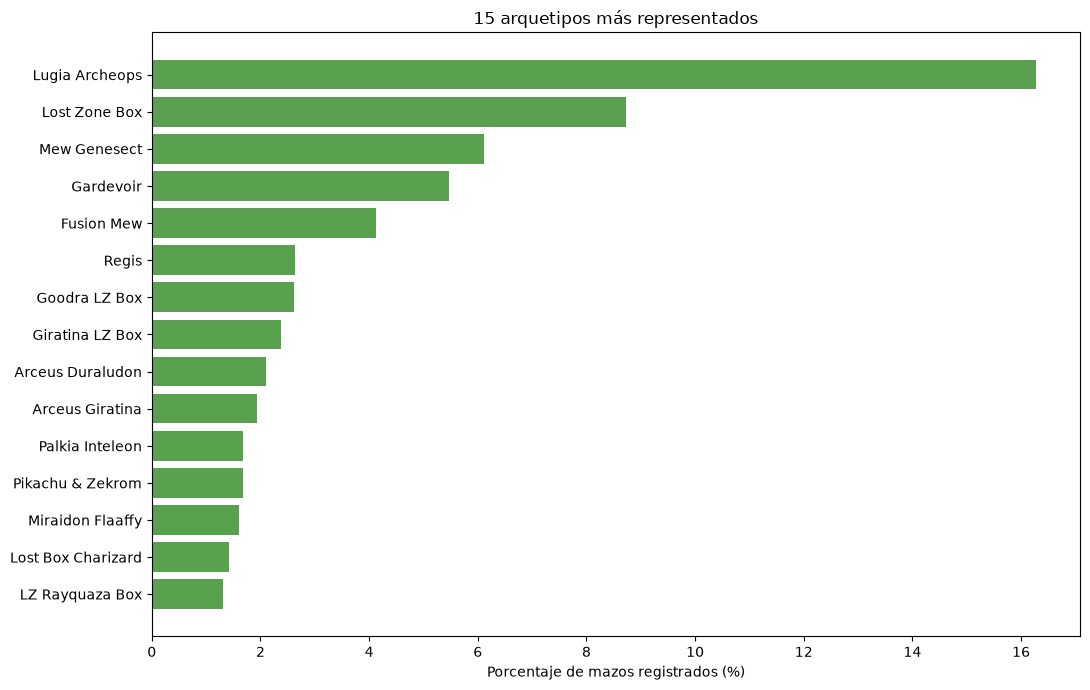

In [84]:
top_15_arquetipos = ranking_arquetipos.head(15).sort_values(
    "porcentaje_mazos",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_15_arquetipos["combo_type_name"],
    top_15_arquetipos["porcentaje_mazos"],
    color="#59A14F"
)

plt.title("15 arquetipos más representados")
plt.xlabel("Porcentaje de mazos registrados (%)")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "../imagenes/03_arquetipos_frecuentes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Presencia de los arquetipos en el top 8

Creamos una variable que indica si el mazo terminó entre las ocho primeras posiciones del torneo.

Calculamos la proporción de top 8 solamente para arquetipos con al menos 30 mazos registrados. Este mínimo evita destacar arquetipos con porcentajes elevados basados en muy pocos casos.

La entrada en top 8 no equivale a una tasa de victorias y también depende del tamaño y la composición de cada torneo.

In [85]:
df_mazos["top_8"] = np.where(
    df_mazos["ranking_player_tournament"] <= 8,
    1,
    0
)

rendimiento_arquetipos = (
    df_mazos.groupby("combo_type_name")
    .agg(
        mazos_registrados=("id_player", "size"),
        apariciones_top_8=("top_8", "sum"),
        proporcion_top_8=("top_8", "mean"),
        posicion_mediana=("ranking_player_tournament", "median")
    )
    .reset_index()
)

rendimiento_arquetipos["porcentaje_top_8"] = (
    rendimiento_arquetipos["proporcion_top_8"] * 100
)

rendimiento_arquetipos_filtrado = (
    rendimiento_arquetipos.loc[
        rendimiento_arquetipos["mazos_registrados"] >= 30
    ]
    .sort_values(
        ["porcentaje_top_8", "mazos_registrados"],
        ascending=[False, False]
    )
)

rendimiento_arquetipos_filtrado.head(15).round(2)

,combo_type_name,mazos_registrados,apariciones_top_8,proporcion_top_8,posicion_mediana,porcentaje_top_8
215,Mewtwo & Mew,35,19,0.54,8.0,54.29
69,Buzzwole Lycanroc,35,12,0.34,21.0,34.29
339,Zacian ADP,44,13,0.30,14.5,29.55
235,Palkia Inteleon,84,23,0.27,22.0,27.38
341,Zapdos,51,12,0.24,16.0,23.53
306,Ultra Malamar,47,11,0.23,24.0,23.40
241,Pikachu & Zekrom,84,19,0.23,31.5,22.62
242,Pikachu & Zekrom Zapdos,31,7,0.23,21.0,22.58
19,Arceus Flying Pikachu,37,8,0.22,41.0,21.62
364,Zoroark Lycanroc,57,12,0.21,29.0,21.05


### Arquetipos con mayor presencia en el top 8

Entre los arquetipos con al menos 30 mazos registrados, comparamos el porcentaje de apariciones que terminaron dentro de las ocho primeras posiciones.

Mewtwo & Mew presenta el porcentaje más elevado, con un 54,29%, seguido de Buzzwole Lycanroc y Zacian ADP.

Estos resultados muestran que los arquetipos más frecuentes no son necesariamente los que presentan una mayor proporción de posiciones en el top 8. Este indicador no representa una tasa de victorias, ya que el conjunto no contiene los resultados individuales de cada partida.

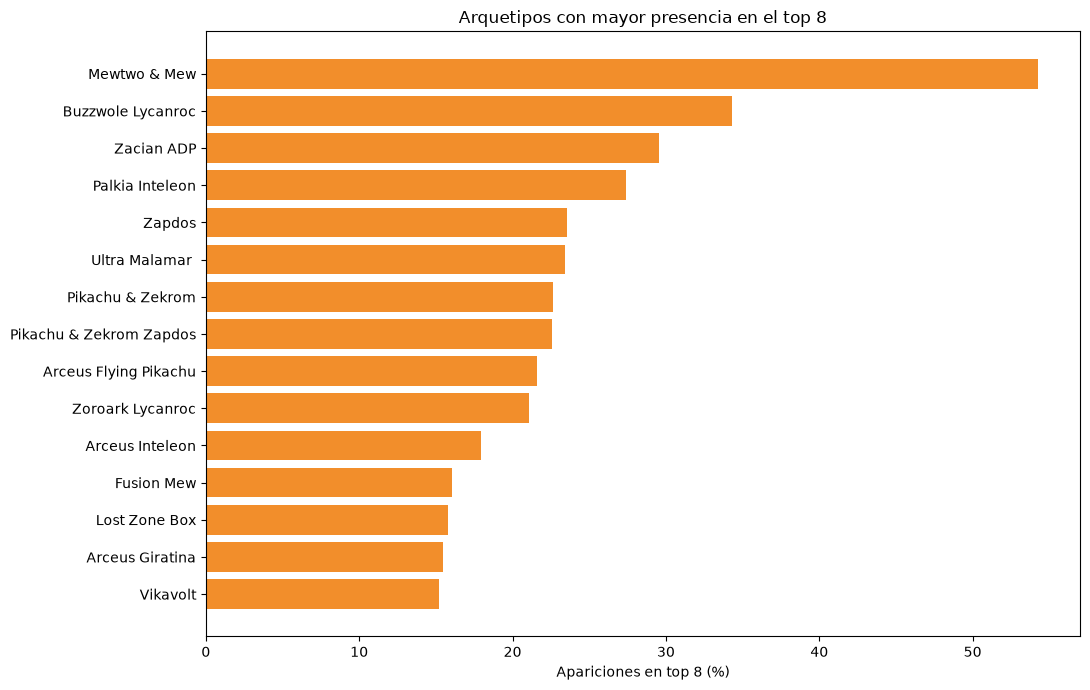

In [86]:
top_15_rendimiento = (
    rendimiento_arquetipos_filtrado
    .head(15)
    .sort_values("porcentaje_top_8", ascending=True)
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_15_rendimiento["combo_type_name"],
    top_15_rendimiento["porcentaje_top_8"],
    color="#F28E2B"
)

plt.title("Arquetipos con mayor presencia en el top 8")
plt.xlabel("Apariciones en top 8 (%)")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "../imagenes/04_arquetipos_top8.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretación

Mewtwo & Mew presenta la mayor proporción de apariciones en top 8 entre los arquetipos con al menos 30 mazos registrados, superando ampliamente al resto.

Sin embargo, los arquetipos con mayor presencia en los datos no coinciden necesariamente con los que obtienen mejores resultados según este indicador. Por ejemplo, Lost Zone Box y Fusion Mew aparecen en muchos más mazos, pero su proporción de top 8 es considerablemente inferior.

Esto muestra que popularidad y rendimiento competitivo son dimensiones diferentes. La proporción de top 8 debe interpretarse únicamente como un indicador de posición final dentro de los torneos registrados y no como una tasa de victorias.

### Evolución de los arquetipos por año

Analizamos qué arquetipos fueron más frecuentes en cada año para observar cómo cambia el metajuego competitivo a lo largo del tiempo.

El objetivo no es comparar directamente arquetipos de épocas distintas, sino identificar qué estrategias tuvieron mayor presencia en cada periodo.

In [87]:
arquetipos_por_anio = (
    df_mazos.groupby(
        ["year_tournament", "combo_type_name"]
    )
    .agg(
        mazos_registrados=("id_player", "size")
    )
    .reset_index()
)

arquetipos_por_anio["ranking_anual"] = (
    arquetipos_por_anio.groupby("year_tournament")[
        "mazos_registrados"
    ]
    .rank(
        method="first",
        ascending=False
    )
)

top_arquetipos_anuales = (
    arquetipos_por_anio.loc[
        arquetipos_por_anio["ranking_anual"] <= 3
    ]
    .sort_values(
        ["year_tournament", "ranking_anual"]
    )
)

top_arquetipos_anuales

,year_tournament,combo_type_name,mazos_registrados,ranking_anual
2,2011,Reshiram Typhlosion,4,1.0
1,2011,Magnezone Yanmega,3,2.0
0,2011,Magnezone Emboar,1,3.0
6,2012,Darkrai Mewtwo,3,1.0
4,2012,Celebi Mewtwo Terrakion,1,2.0
5,2012,Chandelure Accelgor Lock,1,3.0
16,2013,Plasma Kyurem,6,1.0
8,2013,Accelgor Gothitelle,3,2.0
9,2013,Blastoise Keldeo,3,3.0
33,2014,Yveltal Garbodor,13,1.0


#### Arquetipos dominantes por año

La tabla anterior muestra los tres arquetipos con mayor número de mazos registrados en cada año.

La composición cambia considerablemente a lo largo del periodo analizado, lo que refleja la evolución del metajuego y las distintas rotaciones del juego competitivo.

Los primeros años deben interpretarse con cautela porque contienen un número mucho menor de registros que los años más recientes.

In [88]:
arquetipo_principal_anual = (
    arquetipos_por_anio.loc[
        arquetipos_por_anio["ranking_anual"] == 1
    ]
    .sort_values("year_tournament")
)

arquetipo_principal_anual

,year_tournament,combo_type_name,mazos_registrados,ranking_anual
2,2011,Reshiram Typhlosion,4,1.0
6,2012,Darkrai Mewtwo,3,1.0
16,2013,Plasma Kyurem,6,1.0
33,2014,Yveltal Garbodor,13,1.0
47,2015,Night March,8,1.0
76,2016,Night March,17,1.0
100,2017,Drampa Garbodor,12,1.0
197,2018,Zoroark Lycanroc,39,1.0
260,2019,Pikachu & Zekrom,72,1.0
327,2020,Zacian ADP,32,1.0


#### Arquetipo más representado de cada año

Seleccionamos el arquetipo con mayor número de mazos registrados en cada año.

El gráfico permite observar cómo cambia el arquetipo dominante a lo largo del periodo analizado. Las diferencias en el número de mazos también reflejan la desigual cobertura del conjunto de datos entre años, especialmente en los primeros periodos.

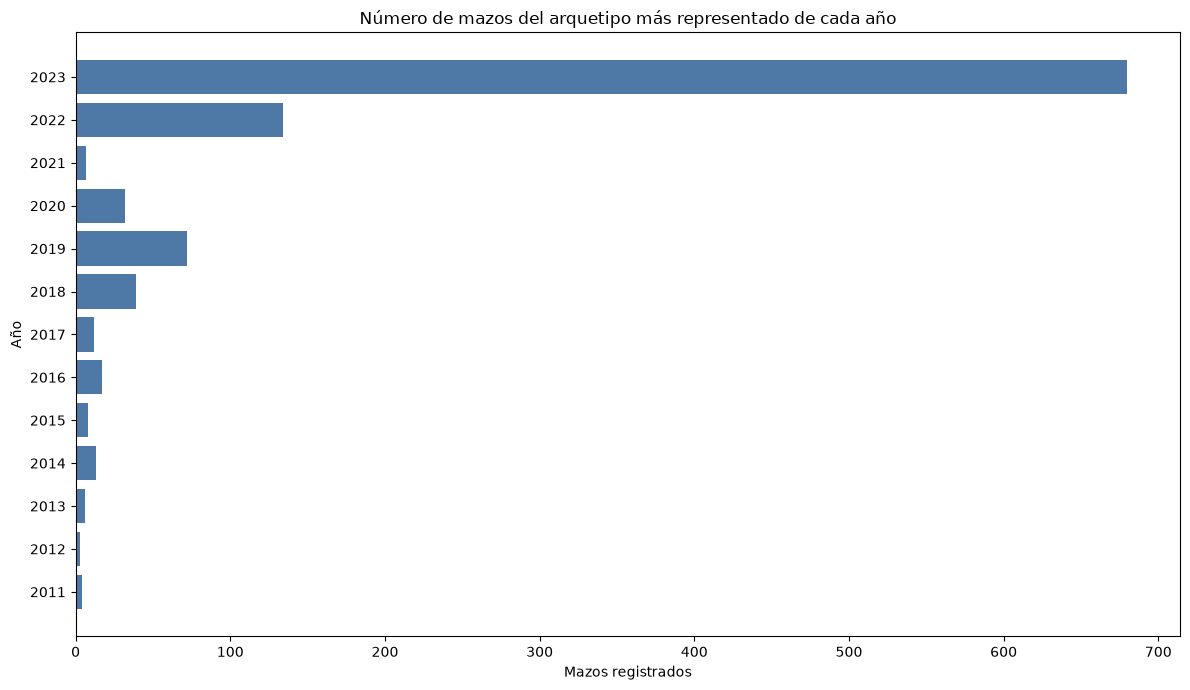

In [89]:
plt.figure(figsize=(12, 7))

plt.barh(
    arquetipo_principal_anual["year_tournament"].astype(str),
    arquetipo_principal_anual["mazos_registrados"],
    color="#4E79A7"
)

plt.title("Número de mazos del arquetipo más representado de cada año")
plt.xlabel("Mazos registrados")
plt.ylabel("Año")

plt.tight_layout()

plt.savefig(
    "../imagenes/05_arquetipo_principal_anual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretación

La presencia del arquetipo más representado varía mucho entre años.

Los años 2022 y 2023 concentran un volumen de registros muy superior al de los primeros periodos, especialmente 2023, donde Lugia Archeops aparece en 680 mazos.

Esta diferencia refleja principalmente la desigual cobertura temporal del conjunto de datos, por lo que las comparaciones entre años deben realizarse con cuidado.

## Análisis estadístico

Antes de aplicar pruebas estadísticas, analizamos la distribución de la posición final de los mazos en los torneos.

Esto nos permitirá decidir qué tipo de prueba es más adecuada y evitar asumir que los datos siguen una distribución normal sin comprobarlo.

In [90]:
estadisticas_posicion = (
    df_mazos["ranking_player_tournament"]
    .describe()
)

estadisticas_posicion

count    5003.000000
mean       47.242654
std        42.020899
min         1.000000
25%        13.000000
50%        35.000000
75%        70.000000
max       193.000000
Name: ranking_player_tournament, dtype: float64

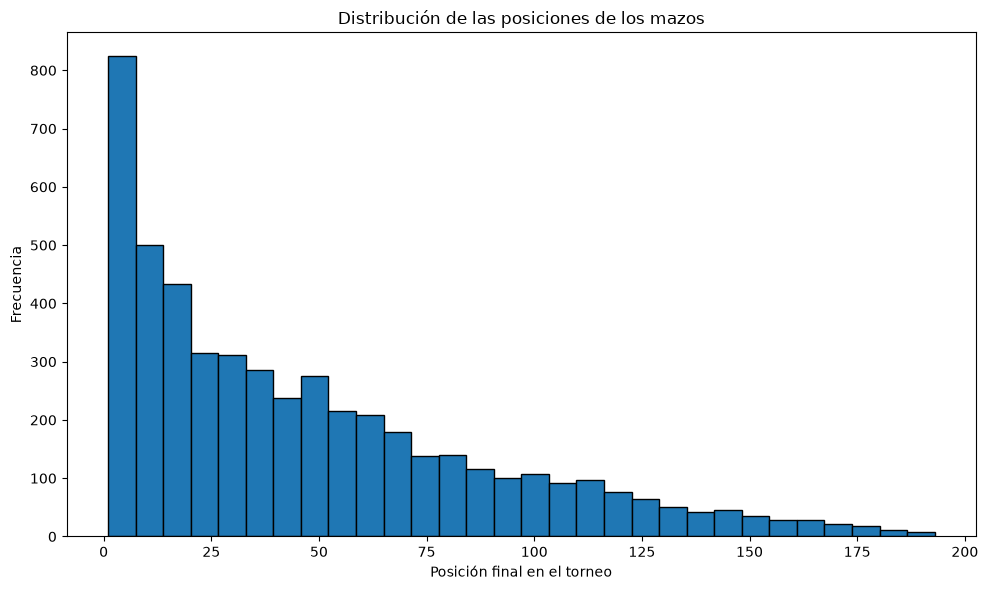

In [91]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_mazos["ranking_player_tournament"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución de las posiciones de los mazos")
plt.xlabel("Posición final en el torneo")
plt.ylabel("Frecuencia")

plt.tight_layout()

plt.show()

#### Interpretación de la distribución

La distribución de las posiciones finales no presenta una forma normal.

La mayor parte de los mazos se concentra en las posiciones más bajas, mientras que existe una cola larga hacia posiciones superiores. Esto produce una distribución asimétrica hacia la derecha.

Por este motivo, la mediana resulta especialmente útil para describir la posición típica de los mazos, ya que se ve menos afectada por los valores extremos que la media.

### Comparación entre mazos top 8 y resto de participantes

Comparamos algunas características numéricas de los mazos que terminaron en el top 8 con las del resto de participantes.

El objetivo es observar si existen diferencias descriptivas entre ambos grupos, sin interpretar estas diferencias como relaciones causales.

In [92]:
comparacion_top8 = (
    df_mazos.groupby("top_8")[
        [
            "ranking_player_tournament",
            "all_time_score"
        ]
    ]
    .agg(["count", "mean", "median"])
    .round(2)
)

comparacion_top8

ranking_player_tournament               all_time_score               
                          count   mean median          count    mean median
top_8                                                                      
0                          4069  57.08   47.0           4069   90.44   30.0
1                           934   4.38    4.0            934  147.05   61.0

#### Interpretación

Los mazos que alcanzaron el top 8 pertenecen a jugadores con un "all_time_score" superior en promedio y mediana al observado en el resto de participantes.

El grupo top 8 presenta un valor medio de 147,05 y una mediana de 61, frente a una media de 90,44 y una mediana de 30 en el resto.

Esta diferencia muestra una asociación entre el historial del jugador y la posición obtenida en los torneos registrados, pero no permite establecer una relación causal.

### Intervalo de confianza de la proporción de top 8

Calculamos un intervalo de confianza del 95% para estimar la proporción de mazos registrados que terminan entre las ocho primeras posiciones.

Este cálculo permite expresar la proporción observada junto con un margen de incertidumbre.

In [93]:
n = len(df_mazos)
proporcion_top8 = df_mazos["top_8"].mean()

error_estandar = np.sqrt(
    proporcion_top8 * (1 - proporcion_top8) / n
)

margen_error = 1.96 * error_estandar

limite_inferior = proporcion_top8 - margen_error
limite_superior = proporcion_top8 + margen_error

print(
    "Proporción de top 8:",
    round(proporcion_top8 * 100, 2),
    "%"
)

print(
    "Intervalo de confianza del 95 %:",
    round(limite_inferior * 100, 2),
    "% -",
    round(limite_superior * 100, 2),
    "%"
)

Proporción de top 8: 18.67 %
Intervalo de confianza del 95 %: 17.59 % - 19.75 %


#### Interpretación

En el conjunto analizado, el 18,67% de los mazos registrados terminó entre las ocho primeras posiciones.

Mediante un intervalo de confianza del 95%, la proporción estimada se sitúa entre el 17,59% y el 19,75%.

Este intervalo describe la incertidumbre estadística de la proporción observada en la muestra analizada y no debe interpretarse como la probabilidad individual de que cualquier mazo alcance el top 8.

## Conclusiones

El análisis muestra que el conjunto de datos permite estudiar tanto la popularidad de cartas y arquetipos como su rendimiento competitivo dentro de los torneos registrados.

Los resultados indican que los arquetipos más utilizados no son necesariamente los que presentan una mayor proporción de apariciones en el top 8. También se observa una fuerte diferencia en la cobertura temporal del conjunto, con una presencia mucho mayor de registros en los años 2022 y 2023.

La distribución de las posiciones finales es asimétrica y los jugadores cuyos mazos alcanzan el top 8 presentan un "all_time_score" superior, tanto en media como en mediana, respecto al resto de participantes.

En el conjunto analizado, el 18,67% de los mazos terminó entre las ocho primeras posiciones, con un intervalo de confianza del 95% situado entre el 17,59% y el 19,75%.

Los resultados deben interpretarse dentro de las limitaciones del conjunto de datos, ya que no se dispone de los resultados de cada partida ni de una cobertura homogénea de todos los torneos y años.

## Exportación de los datos procesados

Guardamos los conjuntos de datos preparados durante el análisis para utilizarlos posteriormente en el dashboard de Power BI y conservar una versión procesada reproducible del proyecto.

In [94]:
df_completo["id_mazo"] = (
    df_completo["id_tournament"].astype(str)
    + "_"
    + df_completo["id_player"].astype(str)
)

df_mazos["id_mazo"] = (
    df_mazos["id_tournament"].astype(str)
    + "_"
    + df_mazos["id_player"].astype(str)
)

print(
    "Identificadores únicos en la tabla de mazos:",
    df_mazos["id_mazo"].is_unique
)

Identificadores únicos en la tabla de mazos: True


In [95]:
df_completo.to_csv(
    "../datos/procesados/pokemon_tcg_completo.csv",
    index=False
)

df_mazos.to_csv(
    "../datos/procesados/pokemon_tcg_mazos.csv",
    index=False
)

print("Datos exportados correctamente")
print("Dataset completo:", df_completo.shape)
print("Dataset de mazos:", df_mazos.shape)

Datos exportados correctamente
Dataset completo: (114207, 33)
Dataset de mazos: (5003, 16)
